### Imports & Setup

In [1]:
import pickle
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap
from pymatgen.core import Composition
from matminer.featurizers.composition import ElementProperty

# AQ-GNoME database + screening filters (stable-entries half)
from aq_gnome import Data_Handler
from aq_gnome.stability import Stability_Criteria, Stable_Entries
from gnome_dreams_oer_screening.vasp.magnetic_enumeration import count_magnetic_sites_from_formula

# EXPLOG (overlay half -- loaded further down)
from gnome_dreams_oer_screening import Explog

# Shared colours/colormaps -- single source of truth in plot_style.py so this
# notebook and oer_results.ipynb stay visually consistent instead of each
# hand-picking their own.
from plot_style import GRAY, MUTED, PALETTE, BLUE, ORANGE, PID_CMAP, OVERPOTENTIAL_CMAP, DEVIATION_CMAP

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

# If True, cache the expensive Magpie/UMAP outputs below to CACHE_DIR and reuse
# them on rerun instead of recomputing; if False, always compute fresh and
# never write to disk.
USE_CACHE = True
CACHE_DIR = Path("cache")
if USE_CACHE:
    CACHE_DIR.mkdir(exist_ok=True)

c:\Users\matnis\OneDrive - Danmarks Tekniske Universitet\Skrivebord\Projects\material_agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Constructing the df of relevant materials
- Applay all filters enforced on the workflow database (before it is made availabul to the agent)
- Disregard all unstable matierals (all benith the minimum threshold of 0.5 eV/atom)

In [2]:
# -- Filtering criteria, applied in the workflow cache ---
ELEMENTS_TO_EXCLUDE = [
    'P', 'B', 'S', 'C', 'F',
    'Tl', 'Pb', 'As', 'Cd', 'Hg',
    'Tc',  'Ra', 'Rf', 'Db', 'Sg', 'Bh', 'Hs',
    'Mt', 'Ds', 'Rg', 'Cn', 'Nh', 'Fl', 'Mc', 'Lv',
    'Ts', 'Og', 'Pm', 'Ac', 'Th', 'Pa', 'U', 'Np',
    'Pu', 'Am', 'Cm', 'Bk', 'Cf', 'Es', 'Fm', 'Md',
    'No', 'Lr', 'Po', 'At', 'Rn'
]
ELEMENTS_TO_INCLUDE = ['O']
MAX_MAGNETIC_SITES = 10


dh = Data_Handler(solid_filter=True, gga_only=False, path_to_data_directory=None)
print("total:", len(dh._working_df))

dh.remove_entries_with_elements(ELEMENTS_TO_EXCLUDE)
dh.remove_entries_without_elements(ELEMENTS_TO_INCLUDE, True)

wdf = dh._working_df
wdf = wdf[wdf["Dimensionality Cheon"] == "3D"]
dh._working_df = wdf
print("after element + dimensionality filters:", len(dh._working_df))

stability_criteria = Stability_Criteria(Us=[1.2, 2.0], pHs=0, decomposition_threshold=0.5)

stable_entries = Stable_Entries(dh, stability_criteria)
stable_df = stable_entries.get_stable_df()
print(f"{len(stable_df)} of {len(dh._working_df)} entries are stable "
      f"({stability_criteria.col_name} < {stability_criteria.decomposition_threshold} eV/atom)")

stable_df = stable_df[stable_df["Composition"].apply(count_magnetic_sites_from_formula) <= MAX_MAGNETIC_SITES]
print(f"{len(stable_df)} pass the magnetic-sites filter (<= {MAX_MAGNETIC_SITES} magnetic atoms)")

total: 528971
Number of entries removed: 231256 Number of entries left: 297715 which is 56.28% of total GNoME database
Removed all entries not containing all of the following elements: O .Number of entries removed: 268327 Number of entries left: 29388 which is 5.56% of total GNoME database
after element + dimensionality filters: 16336
Mixed GGA/GGA(+U)/r2SCAN results will be used for stability analysis.


100%|██████████| 16336/16336 [00:11<00:00, 1445.74it/s]


Found 10425 stable entries given the stability criteria.
10425 of 16336 entries are stable (max_dG_U[1.2,2.0]_pH0 < 0.5 eV/atom)
9431 pass the magnetic-sites filter (<= 10 magnetic atoms)


### Magpie Encoding

In [3]:
MAX_ENCODE = None  # cap on rows to encode; None = encode every row of `stable_df`
                    # (set a small int, e.g. 10, for a fast smoke-test instead)

encode_df = stable_df if MAX_ENCODE is None else stable_df.head(MAX_ENCODE)
encode_df = encode_df.reset_index(drop=True)
compositions = [Composition(c) for c in encode_df["Composition"]]

magpie = ElementProperty.from_preset("magpie")
magpie.set_n_jobs(1) # Experienced bugs (extream slow-down), when appling multiprocessing!

MAGPIE_CACHE_FILE = CACHE_DIR / "X_magpie.npy"
if USE_CACHE and MAGPIE_CACHE_FILE.exists():
    X_magpie = np.load(MAGPIE_CACHE_FILE)
    print(f"loaded cached Magpie features from {MAGPIE_CACHE_FILE} -- {X_magpie.shape}")
else:
    X_magpie = np.array(magpie.featurize_many(compositions, ignore_errors=True))
    print(f"encoded {X_magpie.shape[0]} structures into {X_magpie.shape[1]}-dim Magpie feature vectors")
    if USE_CACHE:
        np.save(MAGPIE_CACHE_FILE, X_magpie)
        print(f"cached to {MAGPIE_CACHE_FILE}")
# encode_df[["MaterialId", "Reduced Formula", stability_criteria.col_name]]

loaded cached Magpie features from cache\X_magpie.npy -- (9431, 132)


### Load EXPLOG + encode

In [4]:
# Frozen EXPLOG snapshot sitting next to this notebook -- same file and loading
# pattern as oer_results.ipynb. Read-only: never touches the live workflow.
EXPLOG_PKL = Path("explog.pkl")

with open(EXPLOG_PKL, "rb") as f:
    payload = pickle.load(f)  # {"candidates_df", "processes_df"}

EXPLOG = Explog()
EXPLOG.init(Path(tempfile.mkdtemp(prefix="explog_probe_")), mode="test")
EXPLOG.relational_frame.candidates.df = payload["candidates_df"]
EXPLOG.relational_frame.processes.df = payload["processes_df"]
EXPLOG.job_handler._recompute_candidate_progress()

candidates = EXPLOG.relational_frame.candidates.df

# A candidate's bulk relaxation can be resubmitted multiple times (magnetic-
# configuration enumeration retries -- see the docstring on the submission
# tool), so "first" = the earliest process_id with job_type ==
# "bulk_relaxation": a proxy for when the candidate first entered the
# campaign, used to colour the UMAP overlay below.
processes = EXPLOG.relational_frame.processes.df
first_bulk_pid = (processes[processes["job_type"] == "bulk_relaxation"]
                  .groupby("candidate_id")["process_id"].min()
                  .rename("first_bulk_process_id"))
candidates = candidates.merge(first_bulk_pid, left_on="candidate_id", right_index=True, how="left")

n_missing_pid = int(candidates["first_bulk_process_id"].isna().sum())
print(f"{len(candidates)} EXPLOG candidates loaded"
      + (f" ({n_missing_pid} with no bulk_relaxation process)" if n_missing_pid else ""))
candidates[["candidate_id", "Reduced Formula", "state", "decision", "first_bulk_process_id"]].head()

139 EXPLOG candidates loaded (2 with no bulk_relaxation process)


,candidate_id,Reduced Formula,state,decision,first_bulk_process_id
0,083fef92df,Fe(PtO3)2,active,Sufficient,0
1,6ace913656,TiSeO5,failed,Abandon,2
2,8ef62845e6,NiSe2O7,active,Sufficient,3
3,54d55ba8f4,CoBiTeO6,active,Sufficient,5
4,01ca2e7942,Zn3Ni(SeO4)4,active,Abandon,7


In [5]:
bulk_p_ids = np.array(candidates["first_bulk_process_id"].values)
bulk_p_ids = bulk_p_ids[~np.isnan(bulk_p_ids)]

print('len, non-nan values:', len(bulk_p_ids))
print('len, unique values:', len(np.unique(bulk_p_ids)))

bulk_p_ids

len, non-nan values: 137
len, unique values: 137


array([   0.,    2.,    3.,    5.,    7.,    8.,    9.,   10.,   11.,
         12.,   14.,   16.,   17.,   21.,   22.,   24.,   28.,   29.,
         33.,   35.,   36.,   40.,   44.,   46.,   49.,   51.,   53.,
         57.,   58.,   60.,   61.,   63.,   67.,   68.,   72.,   76.,
         80.,   84.,   86.,  176.,  654.,  205.,  198.,  190.,  191.,
        195.,  655.,  197.,  203.,  656.,  215.,  213.,  214.,  186.,
        657.,  216.,  217.,  658.,  225.,  178.,  182.,  221.,  199.,
        209.,  254.,  256.,  257.,  261.,  265.,  267.,  271.,  275.,
        279.,  280.,  513.,  515.,  517.,  519.,  520.,  521.,  522.,
        526.,  528.,  532.,  536.,  537.,  541.,  545.,  549.,  553.,
        554.,  555.,  678.,  679.,  680.,  681.,  685.,  689.,  701.,
        702.,  703.,  704.,  706.,  707.,  728.,  729.,  731.,  732.,
        733.,  734.,  735.,  736.,  740.,  744.,  748.,  752.,  837.,
        838.,  842.,  846.,  863.,  864.,  865.,  867.,  869.,  870.,
        871.,  872.,

6 groups detected


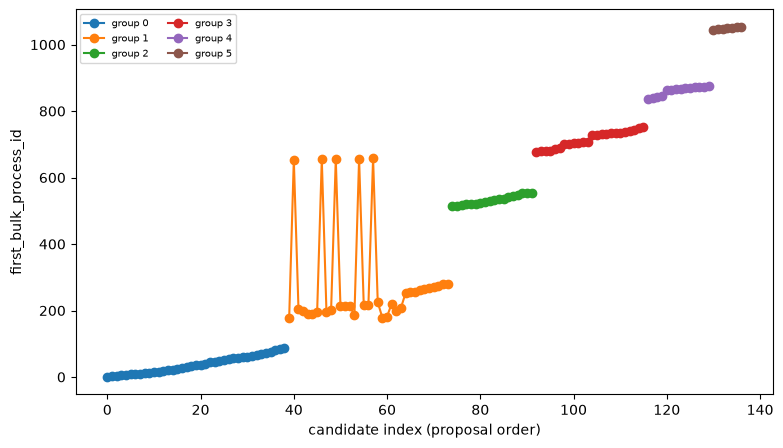

In [6]:
JUMP_THRESHOLD = 50   # minimum increase to flag a candidate group boundary
CONFIRM_LENGTH = 3    # how many points after the jump must stay near the new
                      # (post-jump) level for it to count as a real boundary,
                      # rather than a one-off "forgotten, submitted late" spike

group_ids = np.zeros(len(bulk_p_ids), dtype=int)
current_group = 0

for i in range(len(bulk_p_ids) - 1):
    jump = bulk_p_ids[i + 1] - bulk_p_ids[i]
    if jump > JUMP_THRESHOLD:
        # Confirm against the *post*-jump value, not the pre-jump one -- a
        # spike like 176 -> 654 -> 205 would otherwise "confirm" itself, since
        # 205 > 176 is trivially true even though it clearly reverted.
        window = bulk_p_ids[i + 1 : i + 1 + CONFIRM_LENGTH]
        if np.all(window > bulk_p_ids[i + 1] - JUMP_THRESHOLD):
            current_group += 1
            group_ids[i + 1:] = current_group
        # else: one-off spike -- group count is not increased, these points
        # stay in whatever group already covers this stretch

# Attach back onto `candidates` (aligned via the same non-NaN mask used to
# build bulk_p_ids) so this can be used as an EXPLOG_COLOR_MODE below, same as
# process_id/O_deviation/overpotential_*. Candidates with no bulk_relaxation
# process at all get NaN here too, same as they do for every other mode.
has_bulk_pid = candidates["first_bulk_process_id"].notna().to_numpy()
candidates["batch_group"] = np.nan
candidates.loc[has_bulk_pid, "batch_group"] = group_ids

print(f"{group_ids.max() + 1} groups detected")

fig, ax = plt.subplots(figsize=(9, 5))
idx = np.arange(len(bulk_p_ids))
for g in range(group_ids.max() + 1):
    mask = group_ids == g
    ax.plot(idx[mask], bulk_p_ids[mask], marker="o", linestyle="-", label=f"group {g}")
ax.set_xlabel("candidate index (proposal order)")
ax.set_ylabel("first_bulk_process_id")
ax.legend(fontsize=7, ncol=2)
plt.show()

In [7]:
# Magpie-encode every EXPLOG candidate's Reduced Formula with the same (already-
# fit) featurizer used for stable_df -- shared by the grid-sweep panels below
# (each projects it through their own panel's reducer) and by the final overlay
# plot further down (via the "final" reducer). Reduced Formula (not the full
# Composition) is fine here: Magpie's stats are all atomic-fraction based, so
# they're identical whether computed from e.g. "Cs1S6Zr3" or its reduced
# "CsS2Zr".
#
# We encode every EXPLOG candidate regardless of whether it's in stable_df:
# EXPLOG's candidates were screened with whatever decomposition_threshold the
# agent chose per query at the time, not necessarily our fixed 0.5 eV/atom, so
# some already-explored candidates may fall outside stable_df's cutoff and
# would otherwise be silently dropped from the overlay.
explog_compositions = [Composition(c) for c in candidates["Reduced Formula"]]
X_explog = np.array(magpie.featurize_many(explog_compositions, ignore_errors=True))

n_in_stable = int(candidates["candidate_id"].isin(stable_df["MaterialId"]).sum())
print(f"encoded {len(candidates)} EXPLOG candidates "
      f"({n_in_stable} of them are also in stable_df's {len(stable_df)} stable entries)")

ElementProperty: 100%|██████████| 139/139 [00:00<00:00, 602.86it/s]

encoded 139 EXPLOG candidates (139 of them are also in stable_df's 9431 stable entries)


In [8]:
# Shared EXPLOG colour-mode config -- used by both the grid-sweep plot below
# and the final overlay plot further down, so the two stay consistent (and use
# the exact same colour scale, not just the same colormap). Every mode besides
# "blue" maps to a column in `candidates`.
EXPLOG_COLOR_COLUMN = {
    "process_id": "first_bulk_process_id",
    "O_deviation": "G(O) deviation",
    "overpotential_ideal": "idealOverPotential",
    "overpotential_scaling": "Overpotential_from_scaling",
    "batch_group": "batch_group",
}
EXPLOG_COLOR_CMAP = {
    "process_id": PID_CMAP,
    "O_deviation": DEVIATION_CMAP,
    "overpotential_ideal": OVERPOTENTIAL_CMAP,
    "overpotential_scaling": OVERPOTENTIAL_CMAP,
    "batch_group": "tab10",  # discrete/qualitative, not a continuous metric
}
EXPLOG_COLOR_LABEL = {
    "process_id": "first bulk_relaxation process id",
    "O_deviation": "G(O) deviation [eV]",
    "overpotential_ideal": "ideal overpotential [V]",
    "overpotential_scaling": "overpotential from scaling relation [V]",
    "batch_group": "submission batch group",
}
# (vmin, vmax) per mode, or None to auto-scale to that plot's own data range.
# Fixing these explicitly (rather than leaving them on auto) does two things:
# keeps the colour scale identical across all 9 grid panels and the final
# overlay (they'd already agree numerically today since every plot reads the
# same `candidates` column, but auto-scaling is fragile to that changing), and
# stops a single outlier (e.g. one candidate at ~7 V) from washing out the
# 0-2 V range everything else actually lives in -- values outside the range
# just clip to the end colour instead of stretching the scale.
EXPLOG_COLOR_VLIM = {
    "process_id": None,
    "O_deviation": (0.0, 2.0),
    "overpotential_ideal": (0.0, 2.0),
    "overpotential_scaling": (0.0, 2.0),
    "batch_group": None,
}

### Umap Sweep

In [9]:
# Fit all 9 (n_neighbors, min_dist) combos once, keeping each panel's own
# embedding and its EXPLOG projection (grid_reducer.transform(X_explog)) --
# lets the plot cell below cycle through EXPLOG colour modes instantly without
# redoing any of these (slow) UMAP fits. The fitted reducer itself isn't kept
# around once its EXPLOG projection is captured -- no further use for it.
from itertools import product
from tqdm import tqdm

grid_n_neighbors = [5, 10, 20]
grid_min_dist = [0.5, 0.75, 1.]
grid_params = list(product(enumerate(grid_n_neighbors), enumerate(grid_min_dist)))

grid_results = []
for (i, nn), (j, md) in tqdm(grid_params, desc="UMAP grid"):
    nn = min(nn, len(X_magpie) - 1)
    grid_reducer = umap.UMAP(n_neighbors=nn, min_dist=md, random_state=0, n_jobs=1)
    grid_embedding = grid_reducer.fit_transform(X_magpie)
    grid_embedding_explog = grid_reducer.transform(X_explog)
    grid_results.append({
        "i": i, "j": j, "n_neighbors": nn, "min_dist": md,
        "embedding": grid_embedding,
        "embedding_explog": grid_embedding_explog,
    })

UMAP grid:   0%|          | 0/9 [00:00<?, ?it/s]c:\Users\matnis\OneDrive - Danmarks Tekniske Universitet\Skrivebord\Projects\material_agent\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
UMAP grid:  11%|█         | 1/9 [00:50<06:41, 50.14s/it]c:\Users\matnis\OneDrive - Danmarks Tekniske Universitet\Skrivebord\Projects\material_agent\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
UMAP grid:  22%|██▏       | 2/9 [00:58<02:57, 25.32s/it]c:\Users\matnis\OneDrive - Danmarks Tekniske Universitet\Skrivebord\Projects\material_agent\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
UMAP grid:  33%|███▎      | 3/9 [01:10<01:

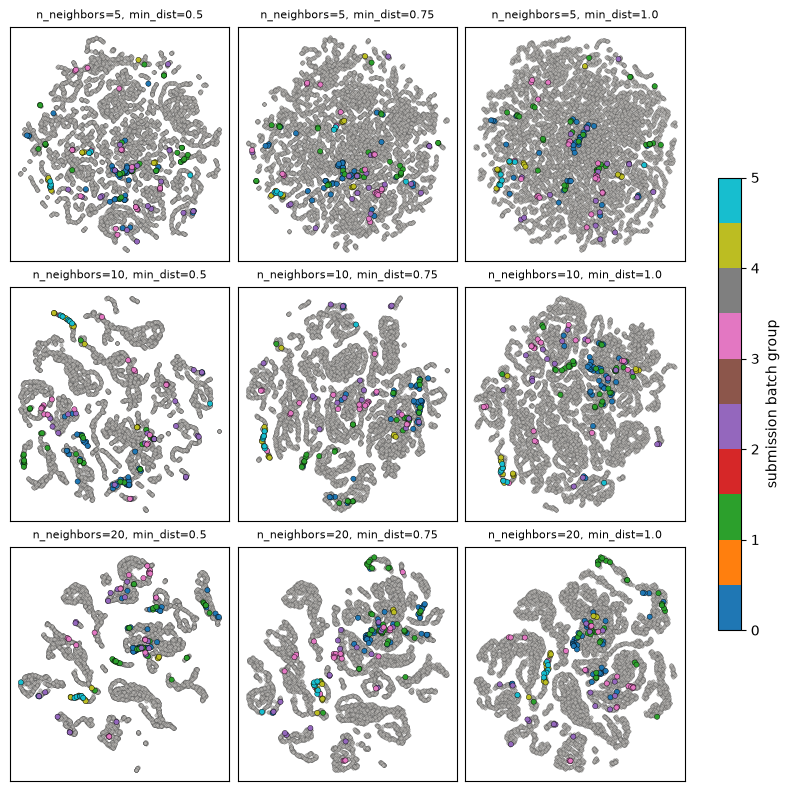

In [15]:
# Redraws the 9 panels from grid_results -- no UMAP calls, so this is cheap to
# rerun while cycling through colour modes. Panels that warned "Graph is not
# fully connected" (small n_neighbors) fell back to random init instead of
# spectral -- a useful signal in itself that n_neighbors is too small for a
# well-behaved layout here.
GRID_COLOR_MODE = "batch_group"  # "blue" | "process_id" | "O_deviation" | "overpotential_ideal" | "overpotential_scaling" | "batch_group"
SHOW_MISSING_AS_BLACK = False    # candidates missing this mode's metric: black marker if True, omitted if False

fig, axes = plt.subplots(len(grid_n_neighbors), len(grid_min_dist),
                          figsize=(2.6 * len(grid_min_dist), 2.6 * len(grid_n_neighbors)),
                          constrained_layout=True)

vmin, vmax = EXPLOG_COLOR_VLIM.get(GRID_COLOR_MODE) or (None, None)

sc = None
for g in grid_results:
    ax = axes[g["i"], g["j"]]
    ax.scatter(g["embedding"][:, 0], g["embedding"][:, 1], s=6, color=GRAY,
               edgecolor="0.3", linewidth=0.2, alpha=0.8)

    if GRID_COLOR_MODE == "blue":
        ax.scatter(g["embedding_explog"][:, 0], g["embedding_explog"][:, 1],
                   s=14, color=BLUE, edgecolor="black", linewidth=0.3)
    else:
        values = candidates[EXPLOG_COLOR_COLUMN[GRID_COLOR_MODE]].to_numpy(dtype=float)
        has_value = ~np.isnan(values)
        sc = ax.scatter(g["embedding_explog"][has_value, 0], g["embedding_explog"][has_value, 1],
                         c=values[has_value], cmap=EXPLOG_COLOR_CMAP[GRID_COLOR_MODE],
                         vmin=vmin, vmax=vmax,
                         s=14, edgecolor="black", linewidth=0.3)
        if SHOW_MISSING_AS_BLACK and (~has_value).any():
            ax.scatter(g["embedding_explog"][~has_value, 0], g["embedding_explog"][~has_value, 1],
                       s=14, color="black", edgecolor="white", linewidth=0.3)

    ax.set_title(f"n_neighbors={g['n_neighbors']}, min_dist={g['min_dist']}", fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])

if sc is not None:
    fig.colorbar(sc, ax=axes, label=EXPLOG_COLOR_LABEL[GRID_COLOR_MODE], shrink=0.6)

plt.show()

In [11]:
# Pick UMAP params from the grid above -- these drive the "final" embedding
# cell below, and (via reducer.transform()) the EXPLOG overlay further down.
CHOSEN_N_NEIGHBORS = 20
CHOSEN_MIN_DIST = 1

loaded cached UMAP reducer from cache\umap_reducer.pkl -- embedding (9431, 2)


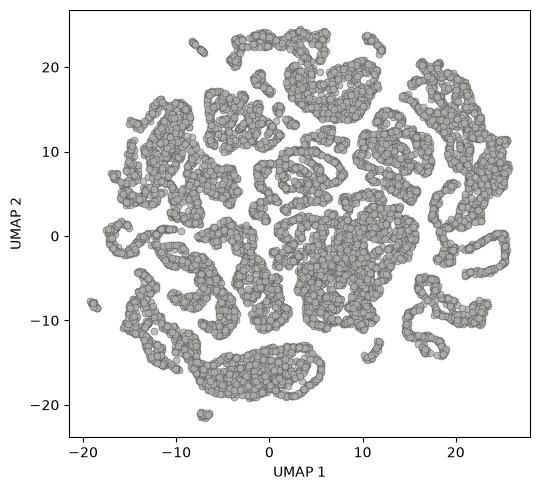

In [12]:
n_neighbors = min(CHOSEN_N_NEIGHBORS, len(X_magpie) - 1)
UMAP_CACHE_FILE = CACHE_DIR / "umap_reducer.pkl"

if USE_CACHE and UMAP_CACHE_FILE.exists():
    with open(UMAP_CACHE_FILE, "rb") as f:
        reducer = pickle.load(f)
    embedding = reducer.embedding_
    print(f"loaded cached UMAP reducer from {UMAP_CACHE_FILE} -- embedding {embedding.shape}")
else:
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=CHOSEN_MIN_DIST, random_state=0, n_jobs=1)
    embedding = reducer.fit_transform(X_magpie)
    if USE_CACHE:
        with open(UMAP_CACHE_FILE, "wb") as f:
            pickle.dump(reducer, f)
        print(f"cached to {UMAP_CACHE_FILE}")

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(embedding[:, 0], embedding[:, 1], s=25, color=GRAY,
           edgecolor="0.3", linewidth=0.4, alpha=0.8, zorder=5)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
fig.tight_layout()
plt.show()

In [13]:
# Project EXPLOG into the "final" chosen embedding space -- not a fresh
# fit_transform, so these points land in the same coordinates as `embedding`.
embedding_explog = reducer.transform(X_explog)

2 EXPLOG candidate(s) missing 'batch_group' -- excluded from the overlay.


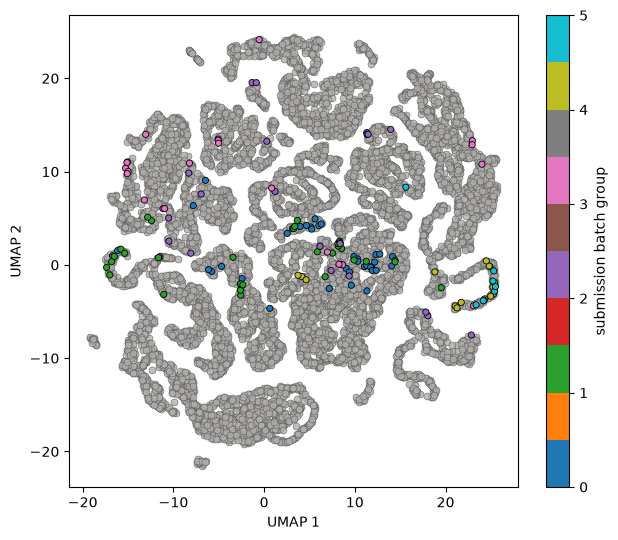

In [14]:
EXPLOG_COLOR_MODE = "batch_group"  # "blue" | "process_id" | "O_deviation" | "overpotential_ideal" | "overpotential_scaling" | "batch_group"
SHOW_MISSING_AS_BLACK = False      # candidates missing this mode's metric: black marker if True, omitted if False

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(embedding[:, 0], embedding[:, 1], s=25, color=GRAY,
           edgecolor="0.3", linewidth=0.4, alpha=0.8, zorder=5,
           label=f"stable AQ-GNoME entries ({len(stable_df)})")

if EXPLOG_COLOR_MODE == "blue":
    ax.scatter(embedding_explog[:, 0], embedding_explog[:, 1], s=45, color=BLUE,
               edgecolor="black", linewidth=0.6, zorder=6,
               label=f"EXPLOG candidates ({len(candidates)})")
else:
    values = candidates[EXPLOG_COLOR_COLUMN[EXPLOG_COLOR_MODE]].to_numpy(dtype=float)
    has_value = ~np.isnan(values)
    n_missing = int((~has_value).sum())
    if n_missing:
        print(f"{n_missing} EXPLOG candidate(s) missing {EXPLOG_COLOR_COLUMN[EXPLOG_COLOR_MODE]!r} -- "
              + ("shown in black." if SHOW_MISSING_AS_BLACK else "excluded from the overlay."))

    vmin, vmax = EXPLOG_COLOR_VLIM.get(EXPLOG_COLOR_MODE) or (None, None)
    sc = ax.scatter(embedding_explog[has_value, 0], embedding_explog[has_value, 1],
                     c=values[has_value], cmap=EXPLOG_COLOR_CMAP[EXPLOG_COLOR_MODE],
                     vmin=vmin, vmax=vmax,
                     s=20, edgecolor="black", linewidth=0.6, zorder=6,
                     label=f"EXPLOG candidates ({int(has_value.sum())})")
    fig.colorbar(sc, ax=ax, label=EXPLOG_COLOR_LABEL[EXPLOG_COLOR_MODE])

    if SHOW_MISSING_AS_BLACK and n_missing:
        ax.scatter(embedding_explog[~has_value, 0], embedding_explog[~has_value, 1],
                   s=20, color="black", edgecolor="white", linewidth=0.6, zorder=6,
                   label=f"EXPLOG candidates missing data ({n_missing})")

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
# ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()